In [1]:

import numpy as np
import pandas as pd
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.metrics import confusion_matrix, accuracy_score, classification_report


print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.19.0


In [2]:

df = pd.read_csv("/content/drive/MyDrive/PROJECTS/WA_Fn-UseC_-Telco-Customer-Churn.csv")


df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [3]:

print("Shape:", df.shape)


df.info()


df.describe()


print("\nMissing Values:\n", df.isna().sum())


print("\nChurn Value Counts:\n", df['Churn'].value_counts())

Shape: (7043, 21)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 n

In [4]:

df = df.drop(columns=['customerID'])


df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


print("NaN in TotalCharges:", df['TotalCharges'].isna().sum())


df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


print("\nMissing values after cleaning:\n", df.isna().sum())

NaN in TotalCharges: 11

Missing values after cleaning:
 gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64


/tmp/ipykernel_2028/1319718342.py:11: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['TotalCharges'].fillna(df['TotalCharges'].median(), inplace=True)


In [5]:

x = df.drop(columns=['Churn'])
y = df['Churn']


print("Features shape:", x.shape)
print("Target shape:", y.shape)


print("\nFeatures:\n", x.head())


print("\nTarget:\n", y.head())

Features shape: (7043, 19)
Target shape: (7043,)

Features:
    gender  SeniorCitizen Partner Dependents  tenure PhoneService  \
0  Female              0     Yes         No       1           No   
1    Male              0      No         No      34          Yes   
2    Male              0      No         No       2          Yes   
3    Male              0      No         No      45           No   
4  Female              0      No         No       2          Yes   

      MultipleLines InternetService OnlineSecurity OnlineBackup  \
0  No phone service             DSL             No          Yes   
1                No             DSL            Yes           No   
2                No             DSL            Yes          Yes   
3  No phone service             DSL            Yes           No   
4                No     Fiber optic             No           No   

  DeviceProtection TechSupport StreamingTV StreamingMovies        Contract  \
0               No          No          No       

In [6]:

le_target = LabelEncoder()
y = le_target.fit_transform(y)

print("Encoded Target (first 10):", y[:10])
print("Classes:", le_target.classes_)


Encoded Target (first 10): [0 0 1 0 1 1 0 0 1 0]
Classes: ['No' 'Yes']


In [7]:

categorical_cols = x.select_dtypes(include='object').columns.tolist()
print("Categorical Columns:", categorical_cols)

Categorical Columns: ['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod']


In [8]:

binary_cols = ['gender', 'Partner', 'Dependents', 'PhoneService',
               'PaperlessBilling', 'MultipleLines']

le = LabelEncoder()
for col in binary_cols:
    x[col] = le.fit_transform(x[col])

print("After Label Encoding:\n", x[binary_cols].head())

After Label Encoding:
    gender  Partner  Dependents  PhoneService  PaperlessBilling  MultipleLines
0       0        1           0             0                 1              1
1       1        0           0             1                 0              0
2       1        0           0             1                 1              0
3       1        0           0             0                 0              1
4       0        0           0             1                 1              0


In [11]:
multi_cols = ['InternetService', 'OnlineSecurity', 'OnlineBackup',
              'DeviceProtection', 'TechSupport', 'StreamingTV',
              'StreamingMovies', 'Contract', 'PaymentMethod']


ct = ColumnTransformer(
    transformers=[('encoder', OneHotEncoder(drop='first', sparse_output=False), multi_cols)],
    remainder='passthrough'
)


x = ct.fit_transform(x)

print("Shape after OneHotEncoding:", x.shape)
print("Feature matrix (first row):\n", x[0])
print("\nType of x after transformation:", type(x))

if isinstance(x, np.ndarray):
    print("Data type of first element in x:", x[0].dtype)
else:

    print("x is not a numpy array. Its type is:", type(x))

Shape after OneHotEncoding: (7043, 29)
Feature matrix (first row):
 [ 0.    0.    0.    0.    0.    1.    0.    0.    0.    0.    0.    0.
  0.    0.    0.    0.    0.    1.    0.    0.    0.    1.    0.    1.
  0.    1.    1.   29.85 29.85]

Type of x after transformation: <class 'numpy.ndarray'>
Data type of first element in x: float64


In [12]:

x_train, x_test, y_train, y_test = train_test_split(
    x, y, test_size=0.2, random_state=0
)

print("Training set size:", x_train.shape)
print("Test set size:", x_test.shape)

Training set size: (5634, 29)
Test set size: (1409, 29)


In [13]:

sc = StandardScaler()


x_train = sc.fit_transform(x_train)


x_test = sc.transform(x_test)

print("Scaled x_train (first row):\n", x_train[0])
print("Scaled x_test (first row):\n", x_test[0])

Scaled x_train (first row):
 [-0.88865502 -0.52628119 -0.52628119  1.57477804 -0.52628119  1.3739541
 -0.52628119  1.37989989 -0.52628119  1.5809424  -0.52628119  1.2563796
 -0.52628119  1.25356634 -0.516093    1.79361809 -0.51857393 -0.71219598
  1.82223822 -1.         -0.4397627   1.03247596 -0.65321536  1.61253221
  0.3262537  -0.98899282 -1.21465857  0.67415397  1.70492806]
Scaled x_test (first row):
 [-0.88865502 -0.52628119 -0.52628119 -0.63501012 -0.52628119  1.3739541
 -0.52628119 -0.72469025 -0.52628119 -0.63253411 -0.52628119  1.2563796
 -0.52628119 -0.79772404  1.93763525 -0.55753229 -0.51857393  1.4041079
 -0.54877567 -1.         -0.4397627  -0.96854556 -0.65321536 -0.54442123
  0.3262537  -0.98899282 -1.21465857 -0.22069469 -0.54691104]


In [15]:

ann = tf.keras.models.Sequential()


ann.add(tf.keras.layers.Dense(units=16, activation='relu'))


ann.add(tf.keras.layers.Dense(units=16, activation='relu'))


ann.add(tf.keras.layers.Dense(units=8, activation='relu'))


ann.add(tf.keras.layers.Dense(units=1, activation='sigmoid'))


ann.build(input_shape=(None, 29))

ann.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_4 (Dense)                 │ (None, 16)             │           480 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 16)             │           272 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 8)              │           136 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 1)              │             9 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 897 (3.50 KB)

 Trainable params: 897 (3.50 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:

ann.compile(
    optimizer='adam',                  # Adam optimizer - adaptive learning rate
    loss='binary_crossentropy',        # Loss function for binary classification
    metrics=['accuracy']               # Monitor accuracy during training
)

print("Model compiled successfully!")

Model compiled successfully!


In [17]:

history = ann.fit(
    x_train, y_train,
    batch_size=32,          # Process 32 samples at a time
    epochs=100,             # Train for 100 complete passes
    validation_split=0.1,   # Use 10% of training data for validation (NEW!)
    verbose=1               # Show training progress
)

print("\nTraining Complete!")

Epoch 1/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 3s 7ms/step - accuracy: 0.6970 - loss: 0.5489 - val_accuracy: 0.8014 - val_loss: 0.4297
Epoch 2/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.7787 - loss: 0.4544 - val_accuracy: 0.8227 - val_loss: 0.4193
Epoch 3/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.7874 - loss: 0.4363 - val_accuracy: 0.8209 - val_loss: 0.4130
Epoch 4/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 2s 7ms/step - accuracy: 0.7907 - loss: 0.4274 - val_accuracy: 0.8121 - val_loss: 0.4118
Epoch 5/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7943 - loss: 0.4202 - val_accuracy: 0.8121 - val_loss: 0.4157
Epoch 6/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 7ms/step - accuracy: 0.7972 - loss: 0.4163 - val_accuracy: 0.8245 - val_loss: 0.4125
Epoch 7/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8034 - loss: 0.4117 - val_accuracy: 0.8262 - val_loss: 0.4159
Epoch 8/100
159/159 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8020 - loss: 0.4096 - val_accu

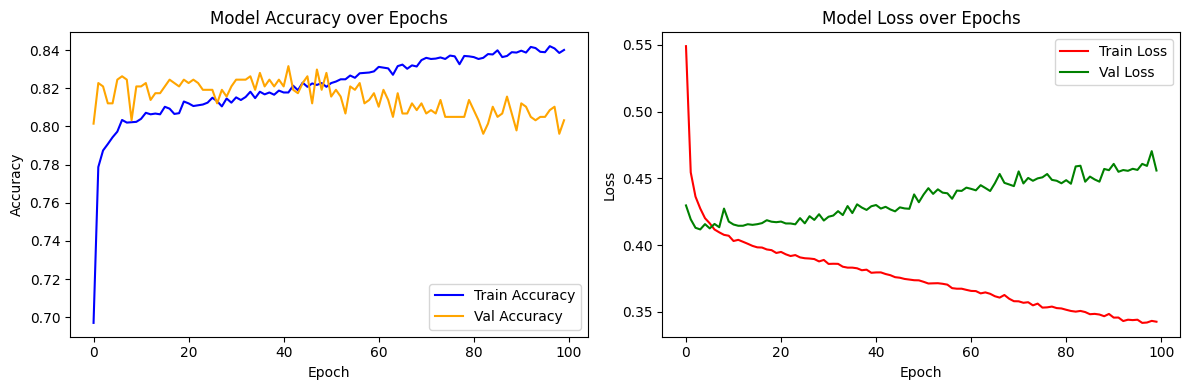

In [18]:

plt.figure(figsize=(12, 4))


plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Train Accuracy', color='blue')
plt.plot(history.history['val_accuracy'], label='Val Accuracy', color='orange')
plt.title('Model Accuracy over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()


plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Train Loss', color='red')
plt.plot(history.history['val_loss'], label='Val Loss', color='green')
plt.title('Model Loss over Epochs')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.tight_layout()
plt.show()

In [19]:

y_pred_prob = ann.predict(x_test)
print("Sample predicted probabilities:\n", y_pred_prob[:5])


y_pred = (y_pred_prob > 0.5).astype(int)
print("\nSample predictions (0=No Churn, 1=Churn):\n", y_pred[:10].flatten())
print("Actual values:\n", y_test[:10])

45/45 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step
Sample predicted probabilities:
 [[0.08284304]
 [0.09015856]
 [0.08464594]
 [0.01489728]
 [0.51476127]]

Sample predictions (0=No Churn, 1=Churn):
 [0 0 0 0 1 1 0 1 0 1]
Actual values:
 [0 0 0 0 0 1 0 1 0 0]


In [20]:

comparison = np.concatenate(
    (y_pred.reshape(len(y_pred), 1),
     y_test.reshape(len(y_test), 1)),
    axis=1
)
print("First 20 rows [Predicted | Actual]:\n")
print(comparison[:20])

First 20 rows [Predicted | Actual]:

[[0 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [1 1]
 [0 0]
 [1 1]
 [0 0]
 [1 0]
 [0 0]
 [0 0]
 [0 0]
 [1 0]
 [0 0]
 [1 1]
 [0 0]
 [0 0]
 [0 0]
 [1 0]]


In [21]:

cm = confusion_matrix(y_test, y_pred)
print("Confusion Matrix:")
print(cm)
print()


acc = accuracy_score(y_test, y_pred)
print(f"Accuracy Score: {acc * 100:.2f}%")
print()


print("Classification Report:")
print(classification_report(y_test, y_pred, target_names=['No Churn', 'Churn']))

Confusion Matrix:
[[885 156]
 [181 187]]

Accuracy Score: 76.08%

Classification Report:
              precision    recall  f1-score   support

    No Churn       0.83      0.85      0.84      1041
       Churn       0.55      0.51      0.53       368

    accuracy                           0.76      1409
   macro avg       0.69      0.68      0.68      1409
weighted avg       0.76      0.76      0.76      1409



In [23]:

sample = pd.DataFrame({
    'gender': [1],
    'SeniorCitizen': [1],
    'Partner': [0],
    'Dependents': [0],
    'tenure': [2],
    'PhoneService': [1],
    'MultipleLines': [0],
    'InternetService': ['Fiber optic'],
    'OnlineSecurity': ['No'],
    'OnlineBackup': ['No'],
    'DeviceProtection': ['No'],
    'TechSupport': ['No'],
    'StreamingTV': ['No'],
    'StreamingMovies': ['No'],
    'Contract': ['Month-to-month'],
    'PaperlessBilling': [1],
    'PaymentMethod': ['Electronic check'],
    'MonthlyCharges': [75.5],
    'TotalCharges': [150.0]
})


sample_encoded = np.array(ct.transform(sample))


sample_scaled = sc.transform(sample_encoded)


prediction_prob = ann.predict(sample_scaled)
prediction = (prediction_prob > 0.5)[0][0]

print(f"Churn Probability: {prediction_prob[0][0]:.4f}")
if prediction:
    print("Prediction: ⚠️ Customer is likely to CHURN!")
else:
    print("Prediction: ✅ Customer is likely to STAY.")

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Churn Probability: 0.7798
Prediction: ⚠️ Customer is likely to CHURN!
